In [1]:
# TODO
# - Directly import .bbl files using orangebox library
# - Figure out issue with yaw axis data collection (I think it needs a chirp sweep at a lower frequency?)

In [1]:
from plant_fit import *

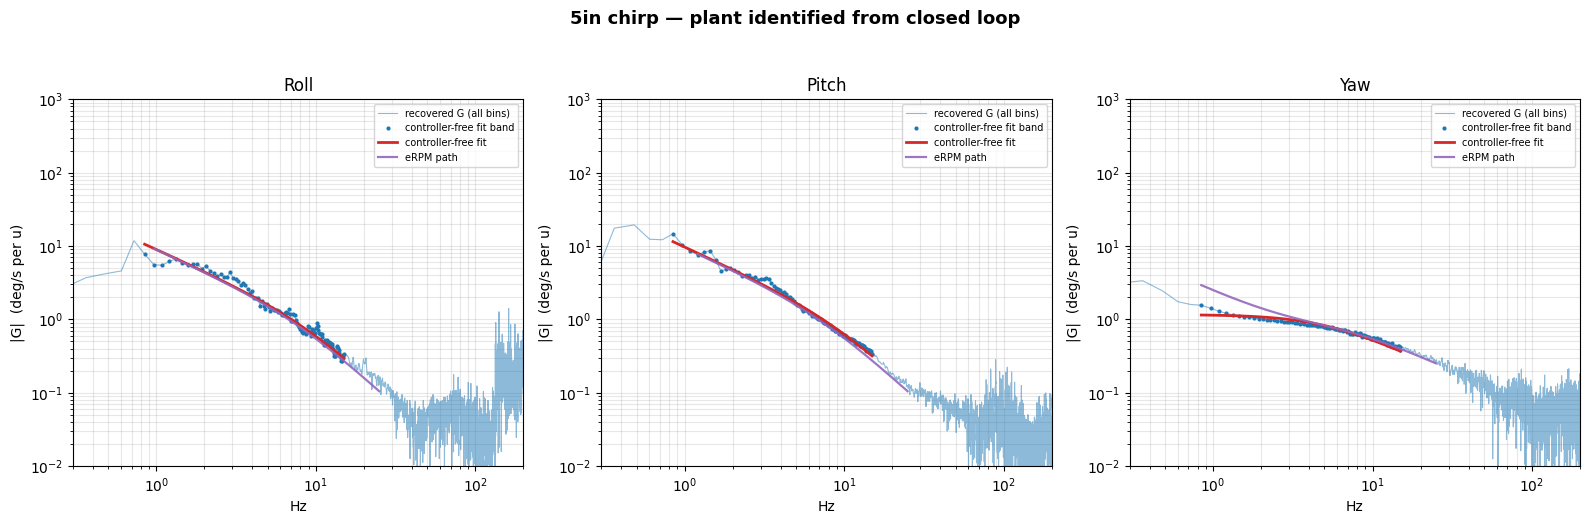

axis,ctrl-free,eRPM,gap
roll,1829 +/- 23,1732 +/- 10,5%
pitch,1950 +/- 19,1787 +/- 9,9%
yaw,1151 +/- 27,1156 +/- 5,0%



[WARNING:   yaw] 2nd pole above the excited band


In [5]:
# Path to betaflight log, should be exported as CSV
csv_path = '5in chirp.csv'
#csv_path = 'Good_tune_wobble_btfl_031.bbl.csv'

# Was this log flown with ADRC?
#   True  - flown with the wc/wo/b0 below. 
#   False - flown with PID (or anything else).
adrc_flight = False
# ADRC parameters flown with (ignored if adrc_flight = False)
wc = {"roll": 40,  "pitch": 40,  "yaw": 40}
wo = {"roll": 100, "pitch": 100, "yaw": 100}
b0 = {"roll": 5000, "pitch": 5000, "yaw": 5000}

# Run the bandwidth / wc analysis?
#   True  - compute and show the bandwidth table (achieved -3dB, vs wc, max wc @45/60 deg,
#           PM at wc), the bandwidth lines in the figure footer, and all warnings.
#   False - skip it (faster). Only the b0 fit is reported, with only the b0-fit warnings
#           (controller mismatch, methods disagree on b0, 2nd pole above excited band).
#           bw_table is returned as None.

# Save the figure and text files to out_dir ('Output metrics')?
#   True  - writes '<log> Plant fit.png', '<log> Plant fit.txt' and '<log> Fit summary tables.txt'
#   False - nothing is written; the figure, tables and warnings are only shown in the notebook
save_outputs = False
suggest_wc = False

# Fit plots of transfer functions, inspect these to make sure they look somewhat reasonable
# If these are nonsensical looking all of the output will be nonsensical

# b0 table with values from each of the fit methods, use your own judgement if these disagree significantly

# From bandwidth table achieved -3dB basically tells the fastest response the system actually keeps up with
# vs wc column has a ratio basically says how fast the controller is responding, this should be around 2x. 
# If this ratio is large (over ~5x) that means something is off, likely b0

# Start tuning with recovered b0 values for each axis for fit that most closely matches recovered G
# This will likely be the controller-free fit band if using a chirp flight

# Yaw plant recovery and subsequent fits are somewhat inconsistent, this seems to be an actual issue with the data
# If a warning appears for the yaw axis saying something extrapolated values, start tuning using wc/wo around
# roll and pitch axis values. 

# If save_outputs = True, results are output into a folder named 'Output metrics'

results, b0_table, bw_table = show_fit_summary(csv_path, wc, wo, b0, f_hi = 15, coh_min = 0.3, adrc_flight = adrc_flight,
                                                    suggest_wc = suggest_wc, save_outputs = save_outputs)
#results, b0_table = show_fit_summary(csv_path, wc, b0, f_hi=15, coh_min=0.3)